In [4]:
pip install numpy pandas matplotlib seaborn

  Using cached numpy-2.2.5-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached pandas-2.2.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.3-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.2-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp313-cp313-win_amd64.whl.metadata (6.3 kB)
  Using cached pillow-11.2.1-cp313-cp313-win_amd64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
Using cached numpy-2.2.5-cp313-cp313-win_amd64.whl (12.6 MB)
Using cached pandas-2.2.3-cp313-cp313-win_amd64.whl (11.5 MB)
Using cached matplotlib-3.10.3-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3-none-any.w

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
path_to_files = '../out/build/vs-debug/media/csv/'

#### Sequential dataframes ####
seq_path = path_to_files + 'seq_w_cyl/'
columns = ['checkpoint', 'frame', 'dt', 'tot_sphs', 'frustum_sphs', 'vis_sphs', 'tot_cyls', 'frustum_cyls', 'vis_cyls', 'top_mipmap_level']
seq_ft = pd.read_csv(seq_path + 'loaded_scene_1AGA.mmtf_frame_times.csv', header=None, names=columns)
seq_ft['fps'] = 1.0 / seq_ft['dt']
seq_occ_ft = pd.read_csv(seq_path + 'occ_loaded_scene_1AGA.mmtf_frame_times.csv', header=None, names=columns)
seq_occ_ft['fps'] = 1.0 / seq_occ_ft['dt']

seq_ft.describe()

,checkpoint,frame,dt,tot_sphs,frustum_sphs,vis_sphs,tot_cyls,frustum_cyls,vis_cyls,top_mipmap_level,fps
count,33990.000000,33990.000000,33990.000000,33990.000000,33990.000000,33990.000000,33990.000000,33990.000000,33990.000000,33990.0,33990.000000
mean,55.053781,2045.759429,0.007945,85.278906,61.295263,61.295263,82.568049,61.955899,61.955899,0.0,138.948372
std,36.767350,1336.419172,0.003020,58.930065,58.356100,58.356100,70.052299,65.870433,65.870433,0.0,39.289346
min,0.000000,0.000000,0.003433,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,6.675924
25%,8.000000,944.000000,0.006169,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,106.902136
50%,51.000000,1888.000000,0.006984,126.000000,20.000000,20.000000,142.000000,26.000000,26.000000,0.0,143.188522
75%,92.000000,2978.000000,0.009354,126.000000,126.000000,126.000000,142.000000,142.000000,142.000000,0.0,162.102797
max,98.000000,5798.000000,0.149792,126.000000,126.000000,126.000000,142.000000,142.000000,142.000000,0.0,291.324361


In [5]:
def mean_dts_between_tracks(df, name=''):
    """
    Calculate the mean dt in a track of checkpoints in a DataFrame.
    """
    df_range_0_10 = df[(df['checkpoint'] >= 0) & (df['checkpoint'] <= 10)]
    df_range_44_54 = df[(df['checkpoint'] >= 44) & (df['checkpoint'] <= 54)]
    df_range_88_98 = df[(df['checkpoint'] >= 88) & (df['checkpoint'] <= 98)]

    df_range_0_10_mean = df_range_0_10.groupby(['tot_sphs', 'tot_cyls'])['fps'].mean().reset_index()
    df_range_44_54_mean = df_range_44_54.groupby(['tot_sphs', 'tot_cyls'])['fps'].mean().reset_index()
    df_range_88_98_mean = df_range_88_98.groupby(['tot_sphs', 'tot_cyls'])['fps'].mean().reset_index()

    print(f"{name} FPS mean (checkpoint 0–10):")
    print(df_range_0_10_mean)
    print(f"{name} FPS mean (checkpoint 44–54):")
    print(df_range_44_54_mean)
    print(f"{name} FPS mean (checkpoint 88–98):")
    print(df_range_88_98_mean)

mean_dts_between_tracks(seq_ft, 'Sequential version without occlusion culling')
print("\n")
mean_dts_between_tracks(seq_occ_ft, 'Sequential version with occlusion culling')

Sequential version without occlusion culling FPS mean (checkpoint 0–10):
   tot_sphs  tot_cyls         fps
0         0       142  106.481913
1       126         0  145.967833
2       126       142   83.000582
Sequential version without occlusion culling FPS mean (checkpoint 44–54):
   tot_sphs  tot_cyls         fps
0         0       142  106.944318
1       126         0  143.417404
2       126       142   77.555167
Sequential version without occlusion culling FPS mean (checkpoint 88–98):
   tot_sphs  tot_cyls         fps
0         0       142  159.703289
1       126         0  194.527473
2       126       142  139.725409


Sequential version with occlusion culling FPS mean (checkpoint 0–10):
   tot_sphs  tot_cyls        fps
0         0       142  27.148784
1       126         0  29.464511
2       126       142  24.551549
Sequential version with occlusion culling FPS mean (checkpoint 44–54):
   tot_sphs  tot_cyls        fps
0         0       142  28.422499
1       126         0  30.5020

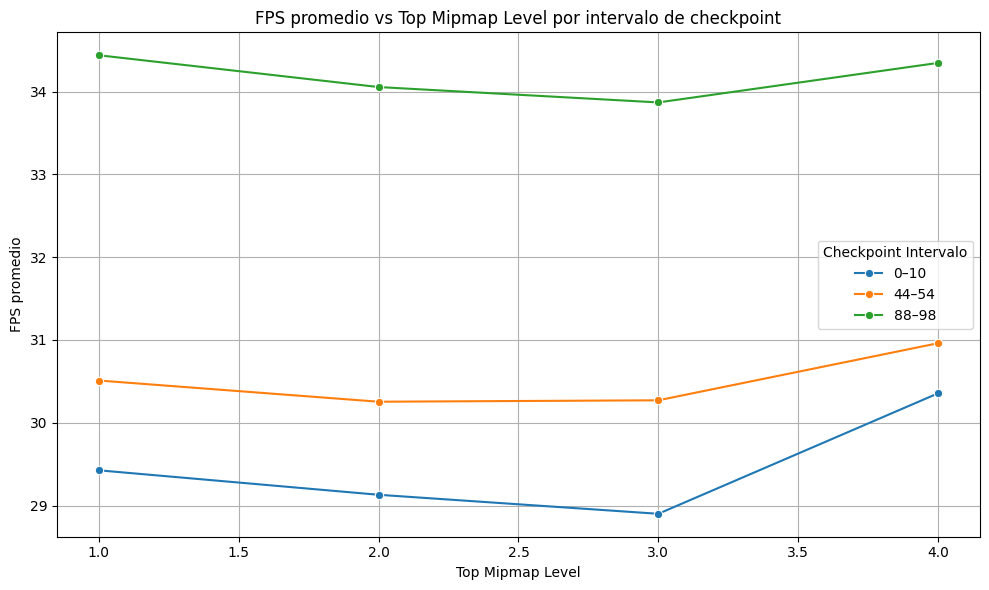

In [4]:
def plot_fps_vs_top_mipmap(df, tot_sphs=126, tot_cyls=0):
    # Asegurar columna FPS
    df = df[(df['tot_sphs'] == tot_sphs) & (df['tot_cyls'] == tot_cyls)].copy()

    # Filtrar por cada intervalo
    intervals = {
        '0–10': df[(df['checkpoint'] >= 0) & (df['checkpoint'] <= 10)],
        '44–54': df[(df['checkpoint'] >= 44) & (df['checkpoint'] <= 54)],
        '88–98': df[(df['checkpoint'] >= 88) & (df['checkpoint'] <= 98)]
    }

    # Preparar DataFrame combinado
    plot_data = []

    for label, df_range in intervals.items():
        grouped = df_range.groupby('top_mipmap_level')['fps'].mean().reset_index()
        grouped['interval'] = label
        plot_data.append(grouped)

    final_df = pd.concat(plot_data, ignore_index=True)

    # Graficar
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=final_df,
        x='top_mipmap_level',
        y='fps',
        hue='interval',
        marker='o'
    )

    plt.title('FPS promedio vs Top Mipmap Level por intervalo de checkpoint')
    plt.xlabel('Top Mipmap Level')
    plt.ylabel('FPS promedio')
    plt.legend(title='Checkpoint Intervalo')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_fps_vs_top_mipmap(seq_occ_ft)

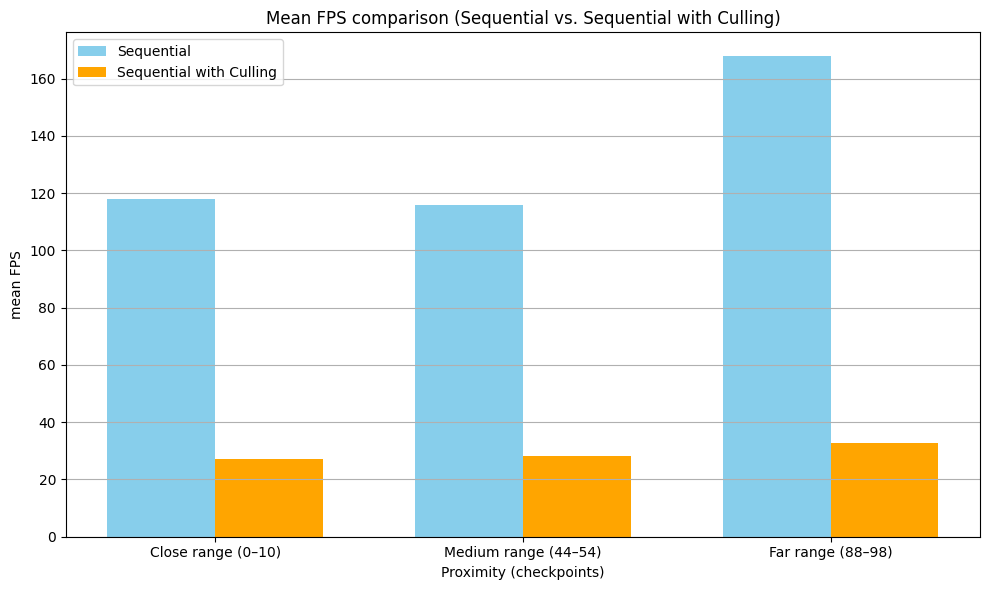

In [22]:
# Función para extraer promedio de FPS por rango de checkpoint
def mean_fps_in_range(df, start, end):
    subset = df[(df['checkpoint'] >= start) & (df['checkpoint'] <= end)]
    return subset['fps'].mean()

# Rangos a evaluar
ranges = [(0, 10), (44, 54), (88, 98)]
labels = ['Close range (0–10)', 'Medium range (44–54)', 'Far range (88–98)']

# Calcular promedios para cada rango
seq_means = [mean_fps_in_range(seq_ft, start, end) for start, end in ranges]
seq_occ_means = [mean_fps_in_range(seq_occ_ft, start, end) for start, end in ranges]

# Crear gráfico de barras
x = range(len(ranges))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], seq_means, width=width, label='Sequential', color='skyblue')
plt.bar([i + width/2 for i in x], seq_occ_means, width=width, label='Sequential with Culling', color='orange')

plt.xlabel('Proximity (checkpoints)')
plt.ylabel('mean FPS')
plt.title('Mean FPS comparison (Sequential vs. Sequential with Culling)')
plt.xticks(x, labels)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

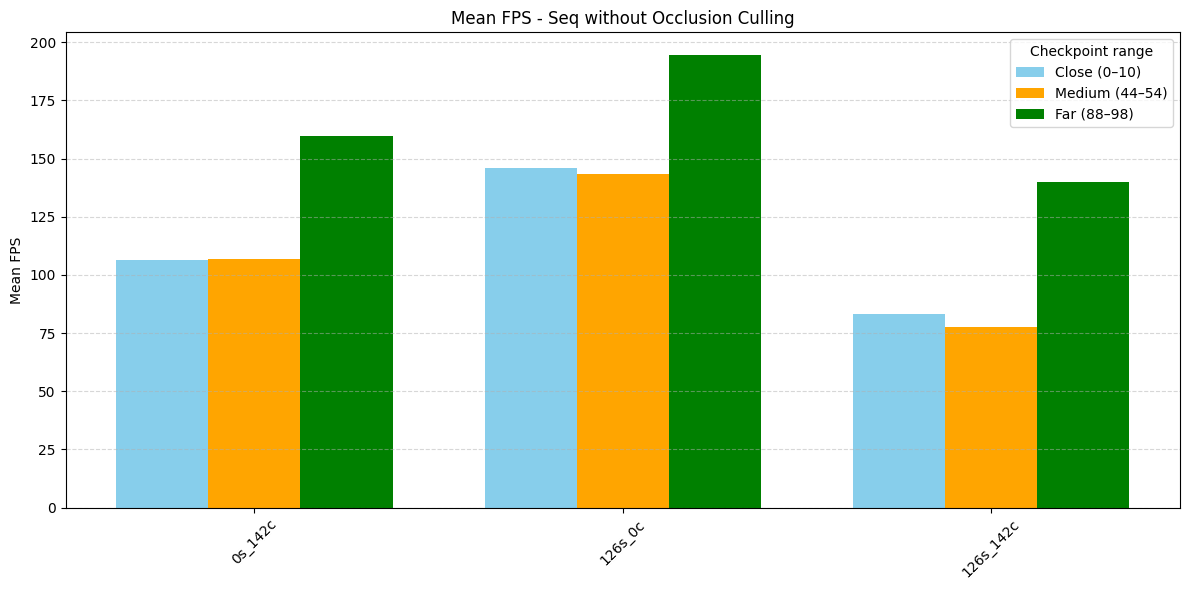

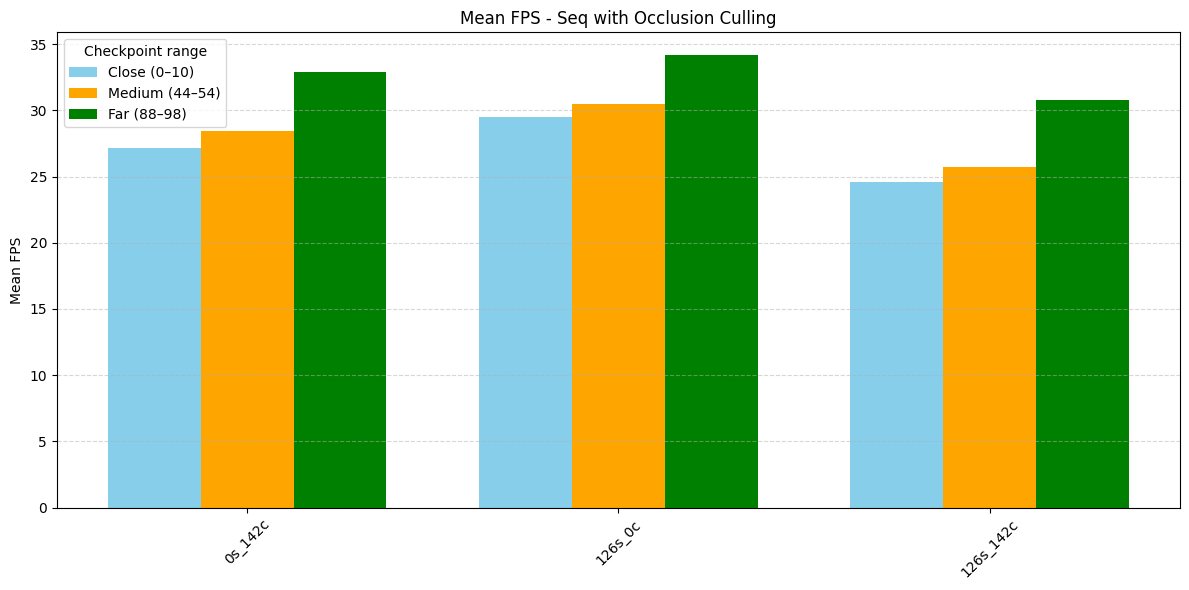

In [26]:
ranges = [(0, 10), (44, 54), (88, 98)]
range_labels = ['Close (0–10)', 'Medium (44–54)', 'Far (88–98)']

# Función de agrupamiento
def group_fps(df, start, end, range_label):
    subset = df[(df['checkpoint'] >= start) & (df['checkpoint'] <= end)]
    grouped = (
        subset.groupby(['tot_sphs', 'tot_cyls'])['fps']
        .mean()
        .reset_index()
    )
    grouped['range'] = range_label
    return grouped

# Agrupar para cada versión
def build_grouped_df(df):
    dfs = []
    for (start, end), label in zip(ranges, range_labels):
        dfs.append(group_fps(df, start, end, label))
    result = pd.concat(dfs, ignore_index=True)
    result['group'] = result['tot_sphs'].astype(str) + 's_' + result['tot_cyls'].astype(str) + 'c'
    return result

df_seq = build_grouped_df(seq_ft)
df_occ = build_grouped_df(seq_occ_ft)

# Gráfico de barras por versión
def plot_version(df_version, title):
    fig, ax = plt.subplots(figsize=(12, 6))
    bar_width = 0.25
    groups = sorted(df_version['group'].unique())
    x = np.arange(len(groups))

    colors = ['skyblue', 'orange', 'green']

    for i, label in enumerate(range_labels):
        subset = df_version[df_version['range'] == label]
        # Asegurar alineamiento con x (llenar vacíos con NaN)
        heights = [subset[(subset['group'] == g)]['fps'].values[0] if not subset[(subset['group'] == g)].empty else np.nan for g in groups]
        ax.bar(x + i * bar_width, heights, width=bar_width, label=label, color=colors[i])

    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(groups, rotation=45)
    ax.set_ylabel("Mean FPS")
    ax.set_title(title)
    ax.legend(title="Checkpoint range")
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Graficar ambas versiones
plot_version(df_seq, "Mean FPS - Seq without Occlusion Culling")
plot_version(df_occ, "Mean FPS - Seq with Occlusion Culling")

In [6]:
#### Fst parallel dataframes ####
fst_parallel_path = path_to_files + 'fst_parallel_w_cyl/'
columns = ['checkpoint', 'frame', 'dt', 'tot_sphs', 'frustum_sphs', 'vis_sphs', 'tot_cyls', 'frustum_cyls', 'vis_cyls', 'top_mipmap_level']

## CPU frustum culling without occlusion culling
fst_parallel_cpu_ft = pd.read_csv(fst_parallel_path + 'loaded_scene_1AGA.mmtf_cpu_frame_times.csv', header=None, names=columns)
fst_parallel_cpu_ft['fps'] = 1.0 / fst_parallel_cpu_ft['dt']

## CPU frustum culling with occlusion culling
fst_parallel_cpu_occ_ft = pd.read_csv(fst_parallel_path + 'occ_loaded_scene_1AGA.mmtf_cpu_frame_times.csv', header=None, names=columns)
fst_parallel_cpu_occ_ft['fps'] = 1.0 / fst_parallel_cpu_occ_ft['dt']

## GPU frustum culling without occlusion culling
fst_parallel_gpu_ft = pd.read_csv(fst_parallel_path + 'loaded_scene_1AGA.mmtf_gpu_frame_times.csv', header=None, names=columns)
fst_parallel_gpu_ft['fps'] = 1.0 / fst_parallel_gpu_ft['dt']

## GPU frustum culling with occlusion culling
fst_parallel_gpu_occ_ft = pd.read_csv(fst_parallel_path + 'occ_loaded_scene_1AGA.mmtf_gpu_frame_times.csv', header=None, names=columns)
fst_parallel_gpu_occ_ft['fps'] = 1.0 / fst_parallel_gpu_occ_ft['dt']

fst_parallel_cpu_ft.describe()

,checkpoint,frame,dt,tot_sphs,frustum_sphs,vis_sphs,tot_cyls,frustum_cyls,vis_cyls,top_mipmap_level,fps
count,28214.000000,28214.000000,28214.000000,28214.000000,28214.000000,28214.000000,28214.000000,28214.000000,28214.000000,28214.0,28214.000000
mean,65.399802,2024.597186,0.009596,84.052102,74.621500,74.621500,92.742397,84.810874,84.810874,0.0,166.411890
std,27.640869,1291.251816,0.016224,59.379575,57.771677,57.771677,67.590163,65.903433,65.903433,0.0,158.599149
min,0.000000,0.000000,0.000658,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,3.542381
25%,47.000000,837.000000,0.006851,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,142.013683
50%,53.000000,1976.000000,0.006945,126.000000,115.000000,115.000000,142.000000,133.000000,133.000000,0.0,143.996774
75%,92.000000,3152.000000,0.007042,126.000000,126.000000,126.000000,142.000000,142.000000,142.000000,0.0,145.966223
max,98.000000,4412.000000,0.282296,126.000000,126.000000,126.000000,142.000000,142.000000,142.000000,0.0,1519.987840


In [7]:
mean_dts_between_tracks(fst_parallel_cpu_ft, 'First parallel version with CPU frustum culling and without occlusion culling')

First parallel version with CPU frustum culling and without occlusion culling FPS mean (checkpoint 0–10):
   tot_sphs  tot_cyls         fps
0         0       142  453.373054
1       126         0  470.727200
2       126       142  233.708926
First parallel version with CPU frustum culling and without occlusion culling FPS mean (checkpoint 44–54):
   tot_sphs  tot_cyls         fps
0         0       142  144.503132
1       126         0  144.334646
2       126       142  145.754018
First parallel version with CPU frustum culling and without occlusion culling FPS mean (checkpoint 88–98):
   tot_sphs  tot_cyls         fps
0         0       142  144.445558
1       126         0  144.220564
2       126       142  144.075129


In [8]:
mean_dts_between_tracks(fst_parallel_cpu_occ_ft, 'First parallel version with CPU frustum culling and occlusion culling')

First parallel version with CPU frustum culling and occlusion culling FPS mean (checkpoint 0–10):
   tot_sphs  tot_cyls        fps
0         0       142  32.052534
1       126         0  41.056233
2       126       142  18.643162
First parallel version with CPU frustum culling and occlusion culling FPS mean (checkpoint 44–54):
   tot_sphs  tot_cyls         fps
0         0       142  144.109560
1       126         0  144.163982
2       126       142  144.066822
First parallel version with CPU frustum culling and occlusion culling FPS mean (checkpoint 88–98):
   tot_sphs  tot_cyls         fps
0         0       142  144.111926
1       126         0  144.299340
2       126       142  144.065152


In [9]:
mean_dts_between_tracks(fst_parallel_gpu_ft, 'First parallel version with GPU frustum culling and without occlusion culling')

First parallel version with GPU frustum culling and without occlusion culling FPS mean (checkpoint 0–10):
   tot_sphs  tot_cyls        fps
0         0       142  37.072583
1       126         0  47.051545
2       126       142  20.885135
First parallel version with GPU frustum culling and without occlusion culling FPS mean (checkpoint 44–54):
   tot_sphs  tot_cyls         fps
0         0       142  144.077454
1       126         0  144.177089
2       126       142  144.092555
First parallel version with GPU frustum culling and without occlusion culling FPS mean (checkpoint 88–98):
   tot_sphs  tot_cyls         fps
0         0       142  144.310076
1       126         0  144.069434
2       126       142  144.059836


In [10]:
mean_dts_between_tracks(fst_parallel_gpu_occ_ft, 'First parallel version with GPU frustum culling and occlusion culling')

First parallel version with GPU frustum culling and occlusion culling FPS mean (checkpoint 0–10):
   tot_sphs  tot_cyls        fps
0         0       142  35.909250
1       126         0  45.134566
2       126       142  20.117109
First parallel version with GPU frustum culling and occlusion culling FPS mean (checkpoint 44–54):
   tot_sphs  tot_cyls         fps
0         0       142  144.016698
1       126         0  144.172783
2       126       142  144.059847
First parallel version with GPU frustum culling and occlusion culling FPS mean (checkpoint 88–98):
   tot_sphs  tot_cyls         fps
0         0       142  144.048074
1       126         0  144.097956
2       126       142  144.251746


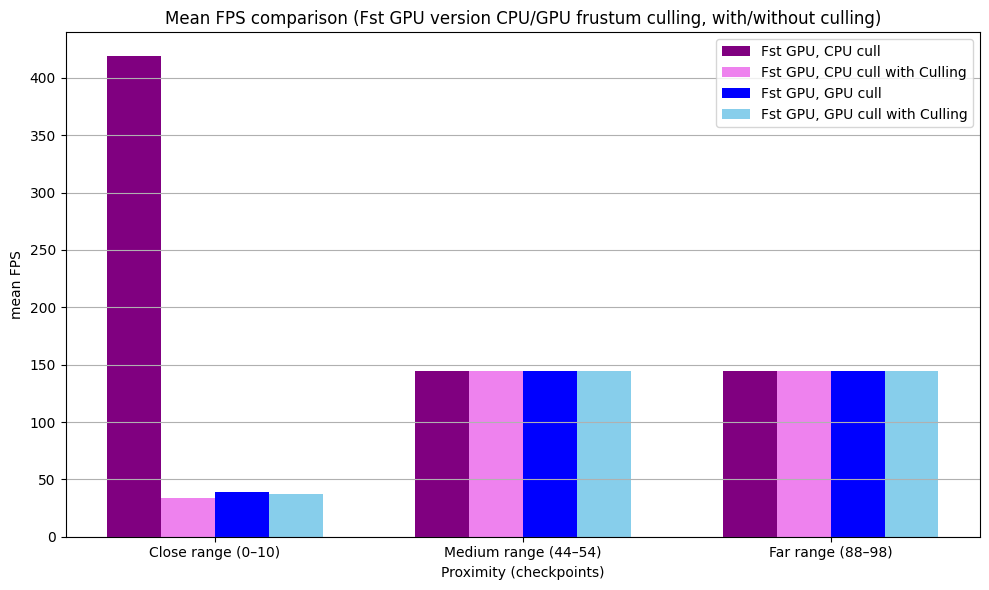

In [ ]:
# Función para extraer promedio de FPS por rango de checkpoint
def mean_fps_in_range(df, start, end):
    subset = df[(df['checkpoint'] >= start) & (df['checkpoint'] <= end)]
    return subset['fps'].mean()

# Rangos a evaluar
ranges = [(0, 10), (44, 54), (88, 98)]
labels = ['Close (0–10)', 'Medium (44–54)', 'Far (88–98)']

# Calcular promedios para cada rango
fst_parallel_cpu_ft_means = [mean_fps_in_range(fst_parallel_cpu_ft, start, end) for start, end in ranges]
fst_parallel_cpu_occ_ft_means = [mean_fps_in_range(fst_parallel_cpu_occ_ft, start, end) for start, end in ranges]
fst_parallel_gpu_ft_means = [mean_fps_in_range(fst_parallel_gpu_ft, start, end) for start, end in ranges]
fst_parallel_gpu_occ_ft_means = [mean_fps_in_range(fst_parallel_gpu_occ_ft, start, end) for start, end in ranges]

# Crear gráfico de barras
x = range(len(ranges))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - 3*width/4 for i in x], fst_parallel_cpu_ft_means, width=width/2.0, label='Fst GPU, CPU cull', color='purple')
plt.bar([i - width/4 for i in x], fst_parallel_cpu_occ_ft_means, width=width/2.0, label='Fst GPU, CPU cull with Culling', color='violet')
plt.bar([i + width/4 for i in x], fst_parallel_gpu_ft_means, width=width/2.0, label='Fst GPU, GPU cull', color='blue')
plt.bar([i + 3*width/4 for i in x], fst_parallel_gpu_occ_ft_means, width=width/2.0, label='Fst GPU, GPU cull with Culling', color='skyblue')

plt.xlabel('Proximity range (checkpoints)')
plt.ylabel('mean FPS')
plt.title('Mean FPS comparison (Fst GPU version CPU/GPU frustum culling, with/without culling)')
plt.xticks(x, labels)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

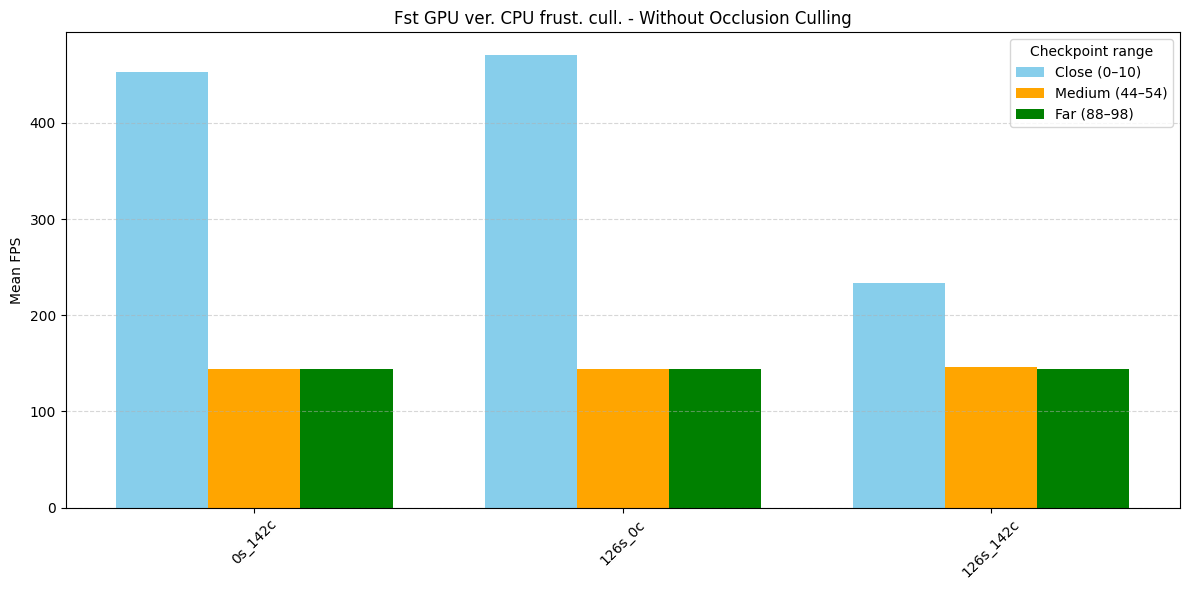

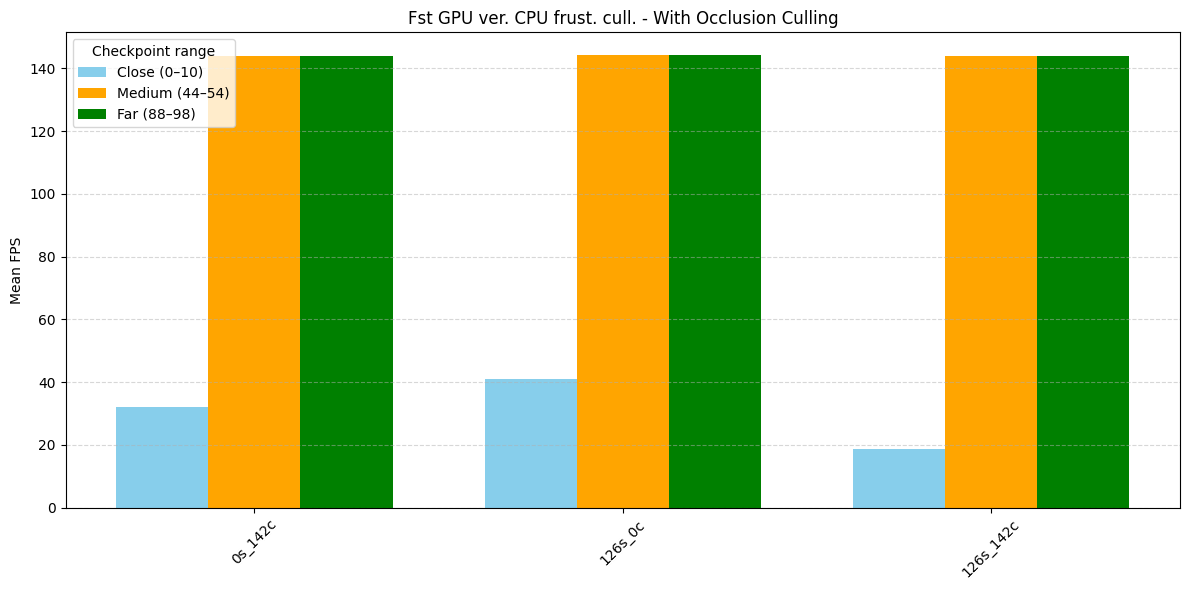

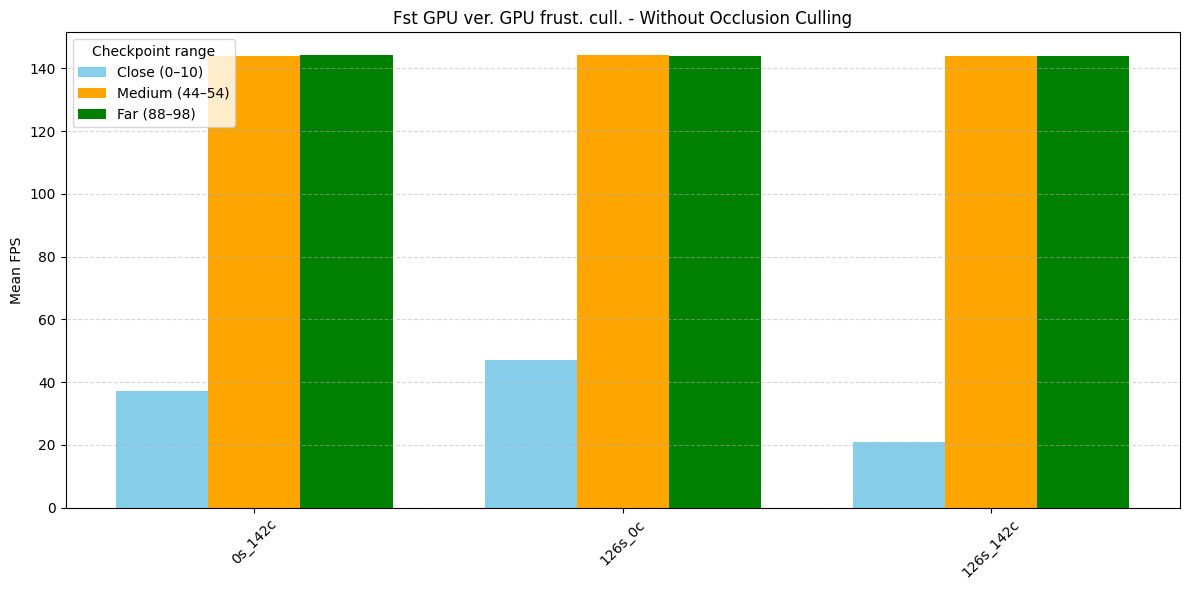

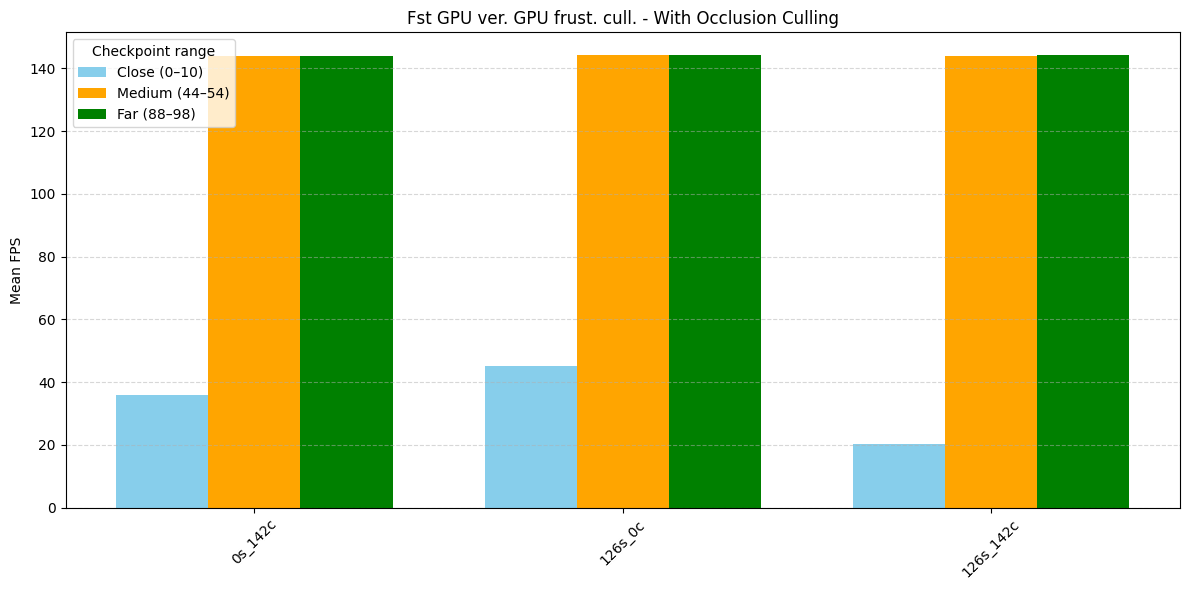

In [18]:
ranges = [(0, 10), (44, 54), (88, 98)]
range_labels = ['Close (0–10)', 'Medium (44–54)', 'Far (88–98)']

# Función de agrupamiento
def group_fps(df, start, end, range_label):
    subset = df[(df['checkpoint'] >= start) & (df['checkpoint'] <= end)]
    grouped = (
        subset.groupby(['tot_sphs', 'tot_cyls'])['fps']
        .mean()
        .reset_index()
    )
    grouped['range'] = range_label
    return grouped

# Agrupar para cada versión
def build_grouped_df(df):
    dfs = []
    for (start, end), label in zip(ranges, range_labels):
        dfs.append(group_fps(df, start, end, label))
    result = pd.concat(dfs, ignore_index=True)
    result['group'] = result['tot_sphs'].astype(str) + 's_' + result['tot_cyls'].astype(str) + 'c'
    return result

df_fst_parallel_cpu_ft = build_grouped_df(fst_parallel_cpu_ft)
df_fst_parallel_cpu_occ_ft = build_grouped_df(fst_parallel_cpu_occ_ft)
df_fst_parallel_gpu_ft = build_grouped_df(fst_parallel_gpu_ft)
df_fst_parallel_gpu_occ_ft = build_grouped_df(fst_parallel_gpu_occ_ft)

# Gráfico de barras por versión
def plot_version(df_version, title):
    fig, ax = plt.subplots(figsize=(12, 6))
    bar_width = 0.25
    groups = sorted(df_version['group'].unique())
    x = np.arange(len(groups))

    colors = ['skyblue', 'orange', 'green']

    for i, label in enumerate(range_labels):
        subset = df_version[df_version['range'] == label]
        # Asegurar alineamiento con x (llenar vacíos con NaN)
        heights = [subset[(subset['group'] == g)]['fps'].values[0] if not subset[(subset['group'] == g)].empty else np.nan for g in groups]
        ax.bar(x + i * bar_width, heights, width=bar_width, label=label, color=colors[i])

    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(groups, rotation=45)
    ax.set_ylabel("Mean FPS")
    ax.set_title(title)
    ax.legend(title="Checkpoint range")
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Graficar ambas versiones
plot_version(df_fst_parallel_cpu_ft, "Fst GPU ver. CPU frust. cull. - Without Occlusion Culling")
plot_version(df_fst_parallel_cpu_occ_ft, "Fst GPU ver. CPU frust. cull. - With Occlusion Culling")
plot_version(df_fst_parallel_gpu_ft, "Fst GPU ver. GPU frust. cull. - Without Occlusion Culling")
plot_version(df_fst_parallel_gpu_occ_ft, "Fst GPU ver. GPU frust. cull. - With Occlusion Culling")

In [19]:
#### Scnd parallel dataframes ####
scnd_parallel_path = path_to_files + 'scnd_parallel_w_cyl/'
columns = ['checkpoint', 'frame', 'dt', 'tot_sphs', 'frustum_sphs', 'vis_sphs', 'tot_cyls', 'frustum_cyls', 'vis_cyls', 'top_mipmap_level']

## CPU frustum culling without occlusion culling
scnd_parallel_cpu_ft = pd.read_csv(scnd_parallel_path + 'loaded_scene_1AGA.mmtf_cpu_frame_times.csv', header=None, names=columns)
scnd_parallel_cpu_ft['fps'] = 1.0 / scnd_parallel_cpu_ft['dt']

## CPU frustum culling with occlusion culling
scnd_parallel_cpu_occ_ft = pd.read_csv(scnd_parallel_path + 'occ_loaded_scene_1AGA.mmtf_cpu_frame_times.csv', header=None, names=columns)
scnd_parallel_cpu_occ_ft['fps'] = 1.0 / scnd_parallel_cpu_occ_ft['dt']

## GPU frustum culling without occlusion culling
scnd_parallel_gpu_ft = pd.read_csv(scnd_parallel_path + 'loaded_scene_1AGA.mmtf_gpu_frame_times.csv', header=None, names=columns)
scnd_parallel_gpu_ft['fps'] = 1.0 / scnd_parallel_gpu_ft['dt']

## GPU frustum culling with occlusion culling
scnd_parallel_gpu_occ_ft = pd.read_csv(scnd_parallel_path + 'occ_loaded_scene_1AGA.mmtf_gpu_frame_times.csv', header=None, names=columns)
scnd_parallel_gpu_occ_ft['fps'] = 1.0 / scnd_parallel_gpu_occ_ft['dt']

scnd_parallel_cpu_ft.describe()

,checkpoint,frame,dt,tot_sphs,frustum_sphs,vis_sphs,tot_cyls,frustum_cyls,vis_cyls,top_mipmap_level,fps
count,40620.000000,40620.000000,40620.000000,40620.000000,40620.000000,40620.000000,40620.000000,40620.000000,40620.000000,40620.0,40620.000000
mean,50.644879,2288.951403,0.006947,80.420384,54.142861,54.142861,96.683752,64.471861,64.471861,4.0,144.355678
std,36.761288,1368.897583,0.000591,60.544368,57.110471,57.110471,66.192543,63.872938,63.872938,0.0,18.396501
min,0.000000,0.000000,0.000520,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.0,8.944784
25%,7.000000,1128.000000,0.006853,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.0,142.170662
50%,49.000000,2256.000000,0.006942,126.000000,18.000000,18.000000,142.000000,28.000000,28.000000,4.0,144.056931
75%,91.000000,3384.250000,0.007034,126.000000,117.000000,117.000000,142.000000,136.000000,136.000000,4.0,145.932142
max,100.000000,6051.000000,0.111797,126.000000,126.000000,126.000000,142.000000,142.000000,142.000000,4.0,1923.076923


In [12]:
mean_dts_between_tracks(scnd_parallel_cpu_ft, 'Second parallel version with CPU frustum culling and without occlusion culling')

Second parallel version with CPU frustum culling and without occlusion culling FPS mean (checkpoint 0–10):
   tot_sphs  tot_cyls         fps
0         0       142  144.249130
1       126         0  144.716060
2       126       142  144.076447
Second parallel version with CPU frustum culling and without occlusion culling FPS mean (checkpoint 44–54):
   tot_sphs  tot_cyls         fps
0         0       142  144.448400
1       126         0  144.126845
2       126       142  145.250175
Second parallel version with CPU frustum culling and without occlusion culling FPS mean (checkpoint 88–98):
   tot_sphs  tot_cyls         fps
0         0       142  144.073139
1       126         0  144.065963
2       126       142  144.070891


In [13]:
mean_dts_between_tracks(scnd_parallel_cpu_occ_ft, 'Second parallel version with CPU frustum culling and occlusion culling')

Second parallel version with CPU frustum culling and occlusion culling FPS mean (checkpoint 0–10):
   tot_sphs  tot_cyls         fps
0         0       142  144.284471
1       126         0  144.081144
2       126       142  144.132342
Second parallel version with CPU frustum culling and occlusion culling FPS mean (checkpoint 44–54):
   tot_sphs  tot_cyls         fps
0         0       142  144.182799
1       126         0  144.062465
2       126       142  144.220014
Second parallel version with CPU frustum culling and occlusion culling FPS mean (checkpoint 88–98):
   tot_sphs  tot_cyls         fps
0         0       142  144.201373
1       126         0  144.070671
2       126       142  144.059038


In [14]:
mean_dts_between_tracks(scnd_parallel_gpu_ft, 'Second parallel version with GPU frustum culling and without occlusion culling')

Second parallel version with GPU frustum culling and without occlusion culling FPS mean (checkpoint 0–10):
   tot_sphs  tot_cyls         fps
0         0       142  144.332002
1       126         0  144.406769
2       126       142  144.064864
Second parallel version with GPU frustum culling and without occlusion culling FPS mean (checkpoint 44–54):
   tot_sphs  tot_cyls         fps
0         0       142  144.427698
1       126         0  144.304887
2       126       142  145.208279
Second parallel version with GPU frustum culling and without occlusion culling FPS mean (checkpoint 88–98):
   tot_sphs  tot_cyls         fps
0         0       142  144.290474
1       126         0  144.273461
2       126       142  145.956236


In [15]:
mean_dts_between_tracks(scnd_parallel_gpu_occ_ft, 'Second parallel version with GPU frustum culling and occlusion culling')

Second parallel version with GPU frustum culling and occlusion culling FPS mean (checkpoint 0–10):
   tot_sphs  tot_cyls         fps
0         0       142  144.312299
1       126         0  144.285007
2       126       142  144.242765
Second parallel version with GPU frustum culling and occlusion culling FPS mean (checkpoint 44–54):
   tot_sphs  tot_cyls         fps
0         0       142  144.496659
1       126         0  144.220906
2       126       142  144.458326
Second parallel version with GPU frustum culling and occlusion culling FPS mean (checkpoint 88–98):
   tot_sphs  tot_cyls         fps
0         0       142  144.299716
1       126         0  144.280926
2       126       142  143.729213


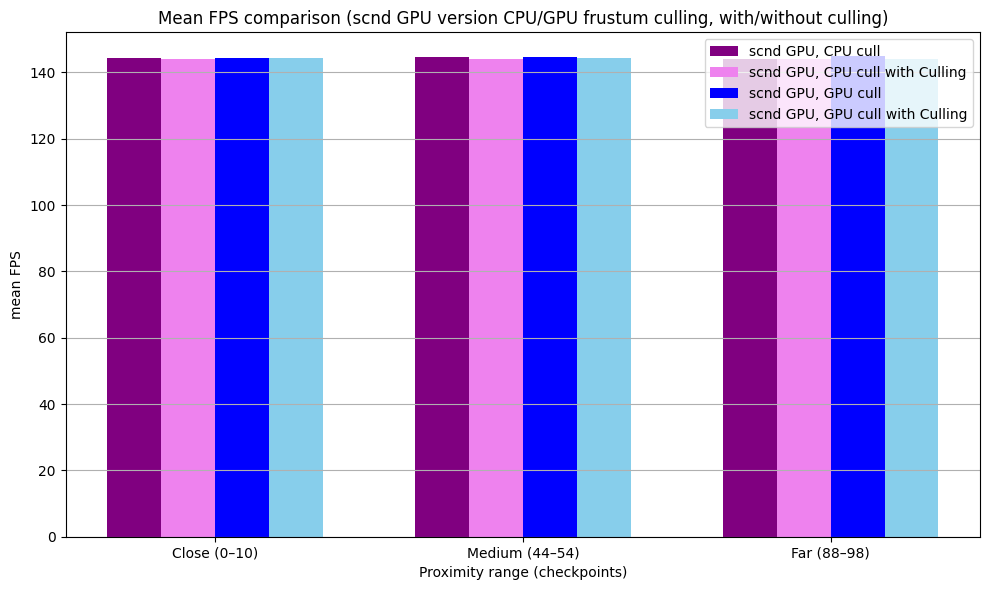

In [ ]:
def mean_fps_in_range(df, start, end):
    subset = df[(df['checkpoint'] >= start) & (df['checkpoint'] <= end)]
    return subset['fps'].mean()

# Rangos a evaluar
ranges = [(0, 10), (44, 54), (88, 98)]
labels = ['Close (0–10)', 'Medium (44–54)', 'Far (88–98)']

# Calcular promedios para cada rango
scnd_parallel_cpu_ft_means = [mean_fps_in_range(scnd_parallel_cpu_ft, start, end) for start, end in ranges]
scnd_parallel_cpu_occ_ft_means = [mean_fps_in_range(scnd_parallel_cpu_occ_ft, start, end) for start, end in ranges]
scnd_parallel_gpu_ft_means = [mean_fps_in_range(scnd_parallel_gpu_ft, start, end) for start, end in ranges]
scnd_parallel_gpu_occ_ft_means = [mean_fps_in_range(scnd_parallel_gpu_occ_ft, start, end) for start, end in ranges]

# Crear gráfico de barras
x = range(len(ranges))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - 3*width/4 for i in x], scnd_parallel_cpu_ft_means, width=width/2.0, label='Scnd GPU, CPU cull', color='purple')
plt.bar([i - width/4 for i in x], scnd_parallel_cpu_occ_ft_means, width=width/2.0, label='Scnd GPU, CPU cull with Culling', color='violet')
plt.bar([i + width/4 for i in x], scnd_parallel_gpu_ft_means, width=width/2.0, label='Scnd GPU, GPU cull', color='blue')
plt.bar([i + 3*width/4 for i in x], scnd_parallel_gpu_occ_ft_means, width=width/2.0, label='Scnd GPU, GPU cull with Culling', color='skyblue')

plt.xlabel('Proximity range (checkpoints)')
plt.ylabel('mean FPS')
plt.title('Mean FPS comparison (Scnd GPU version CPU/GPU frustum culling, with/without culling)')
plt.xticks(x, labels)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

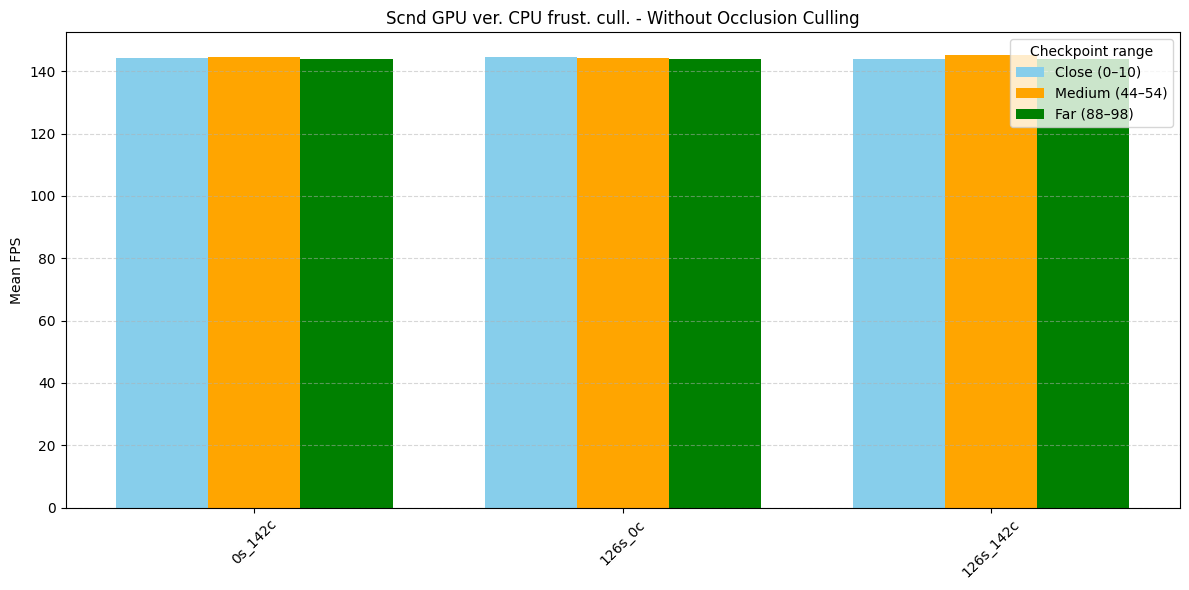

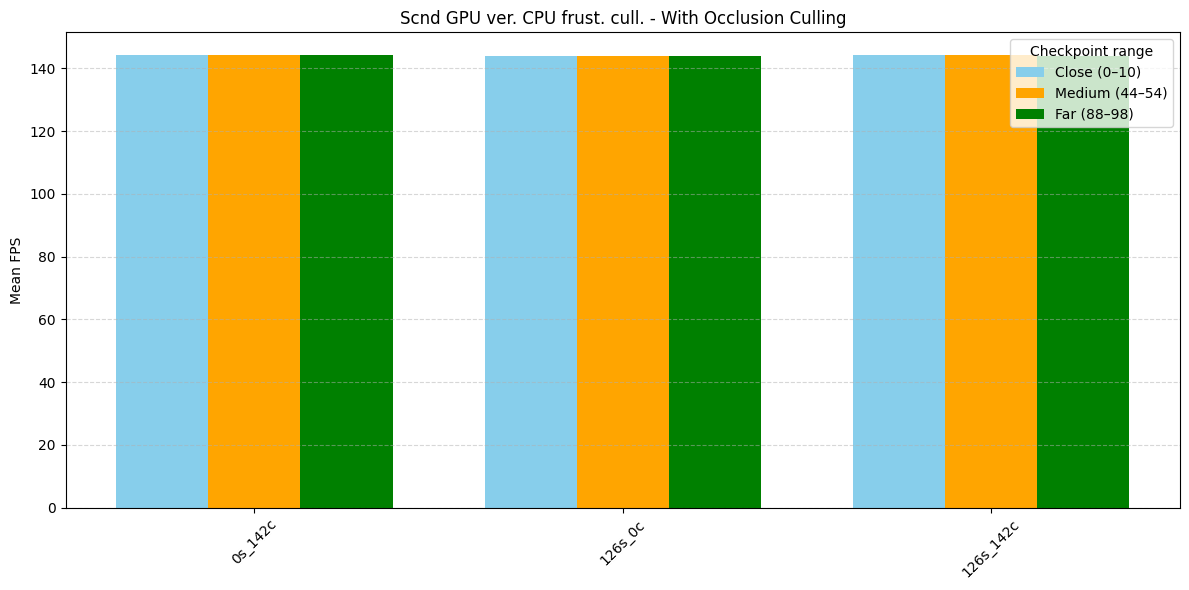

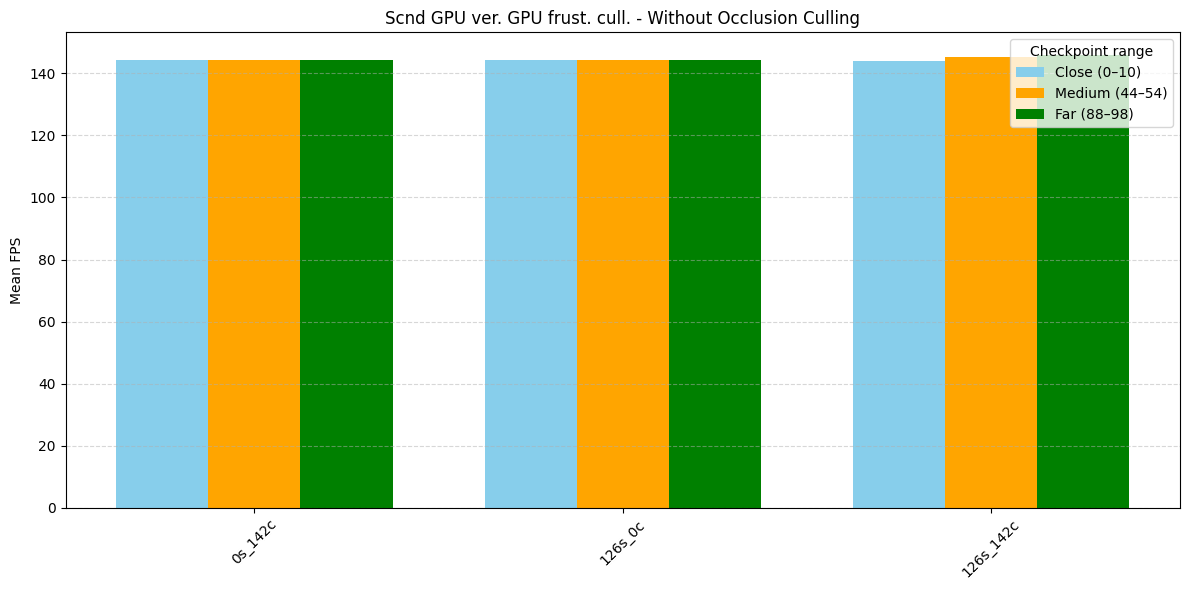

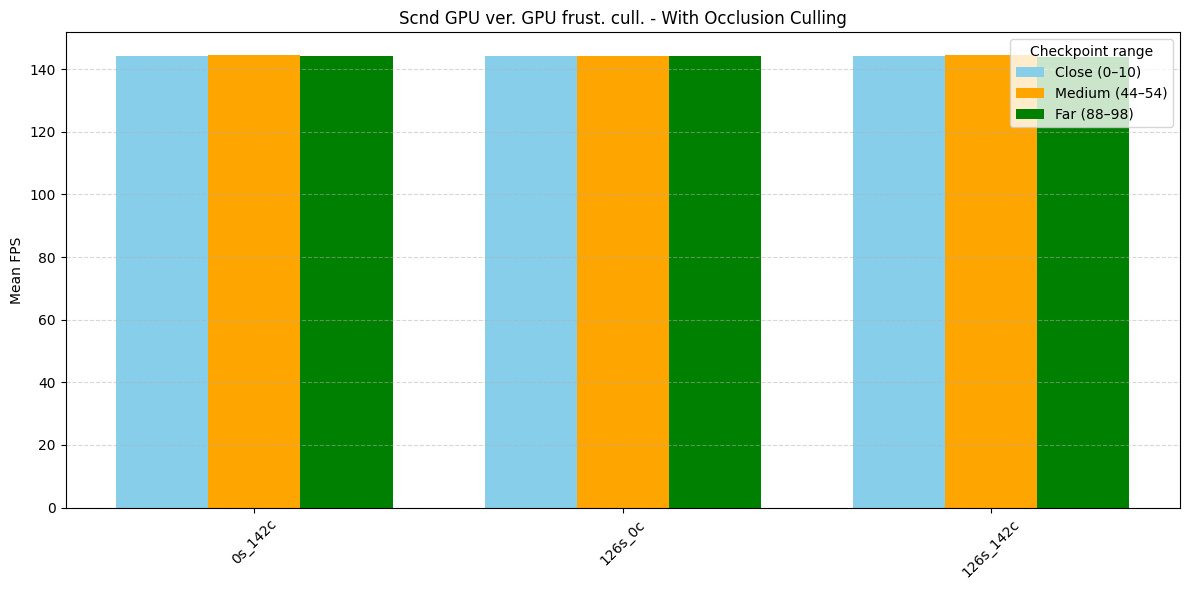

In [21]:
ranges = [(0, 10), (44, 54), (88, 98)]
range_labels = ['Close (0–10)', 'Medium (44–54)', 'Far (88–98)']

# Función de agrupamiento
def group_fps(df, start, end, range_label):
    subset = df[(df['checkpoint'] >= start) & (df['checkpoint'] <= end)]
    grouped = (
        subset.groupby(['tot_sphs', 'tot_cyls'])['fps']
        .mean()
        .reset_index()
    )
    grouped['range'] = range_label
    return grouped

# Agrupar para cada versión
def build_grouped_df(df):
    dfs = []
    for (start, end), label in zip(ranges, range_labels):
        dfs.append(group_fps(df, start, end, label))
    result = pd.concat(dfs, ignore_index=True)
    result['group'] = result['tot_sphs'].astype(str) + 's_' + result['tot_cyls'].astype(str) + 'c'
    return result

df_scnd_parallel_cpu_ft = build_grouped_df(scnd_parallel_cpu_ft)
df_scnd_parallel_cpu_occ_ft = build_grouped_df(scnd_parallel_cpu_occ_ft)
df_scnd_parallel_gpu_ft = build_grouped_df(scnd_parallel_gpu_ft)
df_scnd_parallel_gpu_occ_ft = build_grouped_df(scnd_parallel_gpu_occ_ft)

# Gráfico de barras por versión
def plot_version(df_version, title):
    fig, ax = plt.subplots(figsize=(12, 6))
    bar_width = 0.25
    groups = sorted(df_version['group'].unique())
    x = np.arange(len(groups))

    colors = ['skyblue', 'orange', 'green']

    for i, label in enumerate(range_labels):
        subset = df_version[df_version['range'] == label]
        # Asegurar alineamiento con x (llenar vacíos con NaN)
        heights = [subset[(subset['group'] == g)]['fps'].values[0] if not subset[(subset['group'] == g)].empty else np.nan for g in groups]
        ax.bar(x + i * bar_width, heights, width=bar_width, label=label, color=colors[i])

    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(groups, rotation=45)
    ax.set_ylabel("Mean FPS")
    ax.set_title(title)
    ax.legend(title="Checkpoint range")
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Graficar ambas versiones
plot_version(df_scnd_parallel_cpu_ft, "Scnd GPU ver. CPU frust. cull. - Without Occlusion Culling")
plot_version(df_scnd_parallel_cpu_occ_ft, "Scnd GPU ver. CPU frust. cull. - With Occlusion Culling")
plot_version(df_scnd_parallel_gpu_ft, "Scnd GPU ver. GPU frust. cull. - Without Occlusion Culling")
plot_version(df_scnd_parallel_gpu_occ_ft, "Scnd GPU ver. GPU frust. cull. - With Occlusion Culling")